In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import  OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

#**DATA LOADING**

In [2]:
df = pd.read_csv('calories.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


# **DATA PREPOCESSING**

## Nilai yang Duplikat dan Kosong


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


- Data ini tidak memiliki nilai yang null dan duplikat

## Menghapus kolom ID

In [5]:
df.drop('User_ID', axis=1, inplace=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


In [6]:
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


## Melakukan Normalisasi Menggunakan MinMaxScaler

In [7]:
scaler = MinMaxScaler()
numeric_features = [
    'Age' , 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories'
]
df[numeric_features] = scaler.fit_transform(df[numeric_features])


In [8]:
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,0.813559,0.676768,0.604167,0.965517,0.622951,0.840909,0.734824
1,female,0.000000,0.434343,0.250000,0.448276,0.442623,0.727273,0.207668
2,male,0.830508,0.565657,0.447917,0.137931,0.344262,0.363636,0.079872
3,female,0.237288,0.565657,0.364583,0.413793,0.540984,0.772727,0.223642
4,female,0.118644,0.313131,0.229167,0.310345,0.229508,0.613636,0.108626


## Pengecekan Outlier menggunakan Boxplot Pada Tiap Fitur Numerik

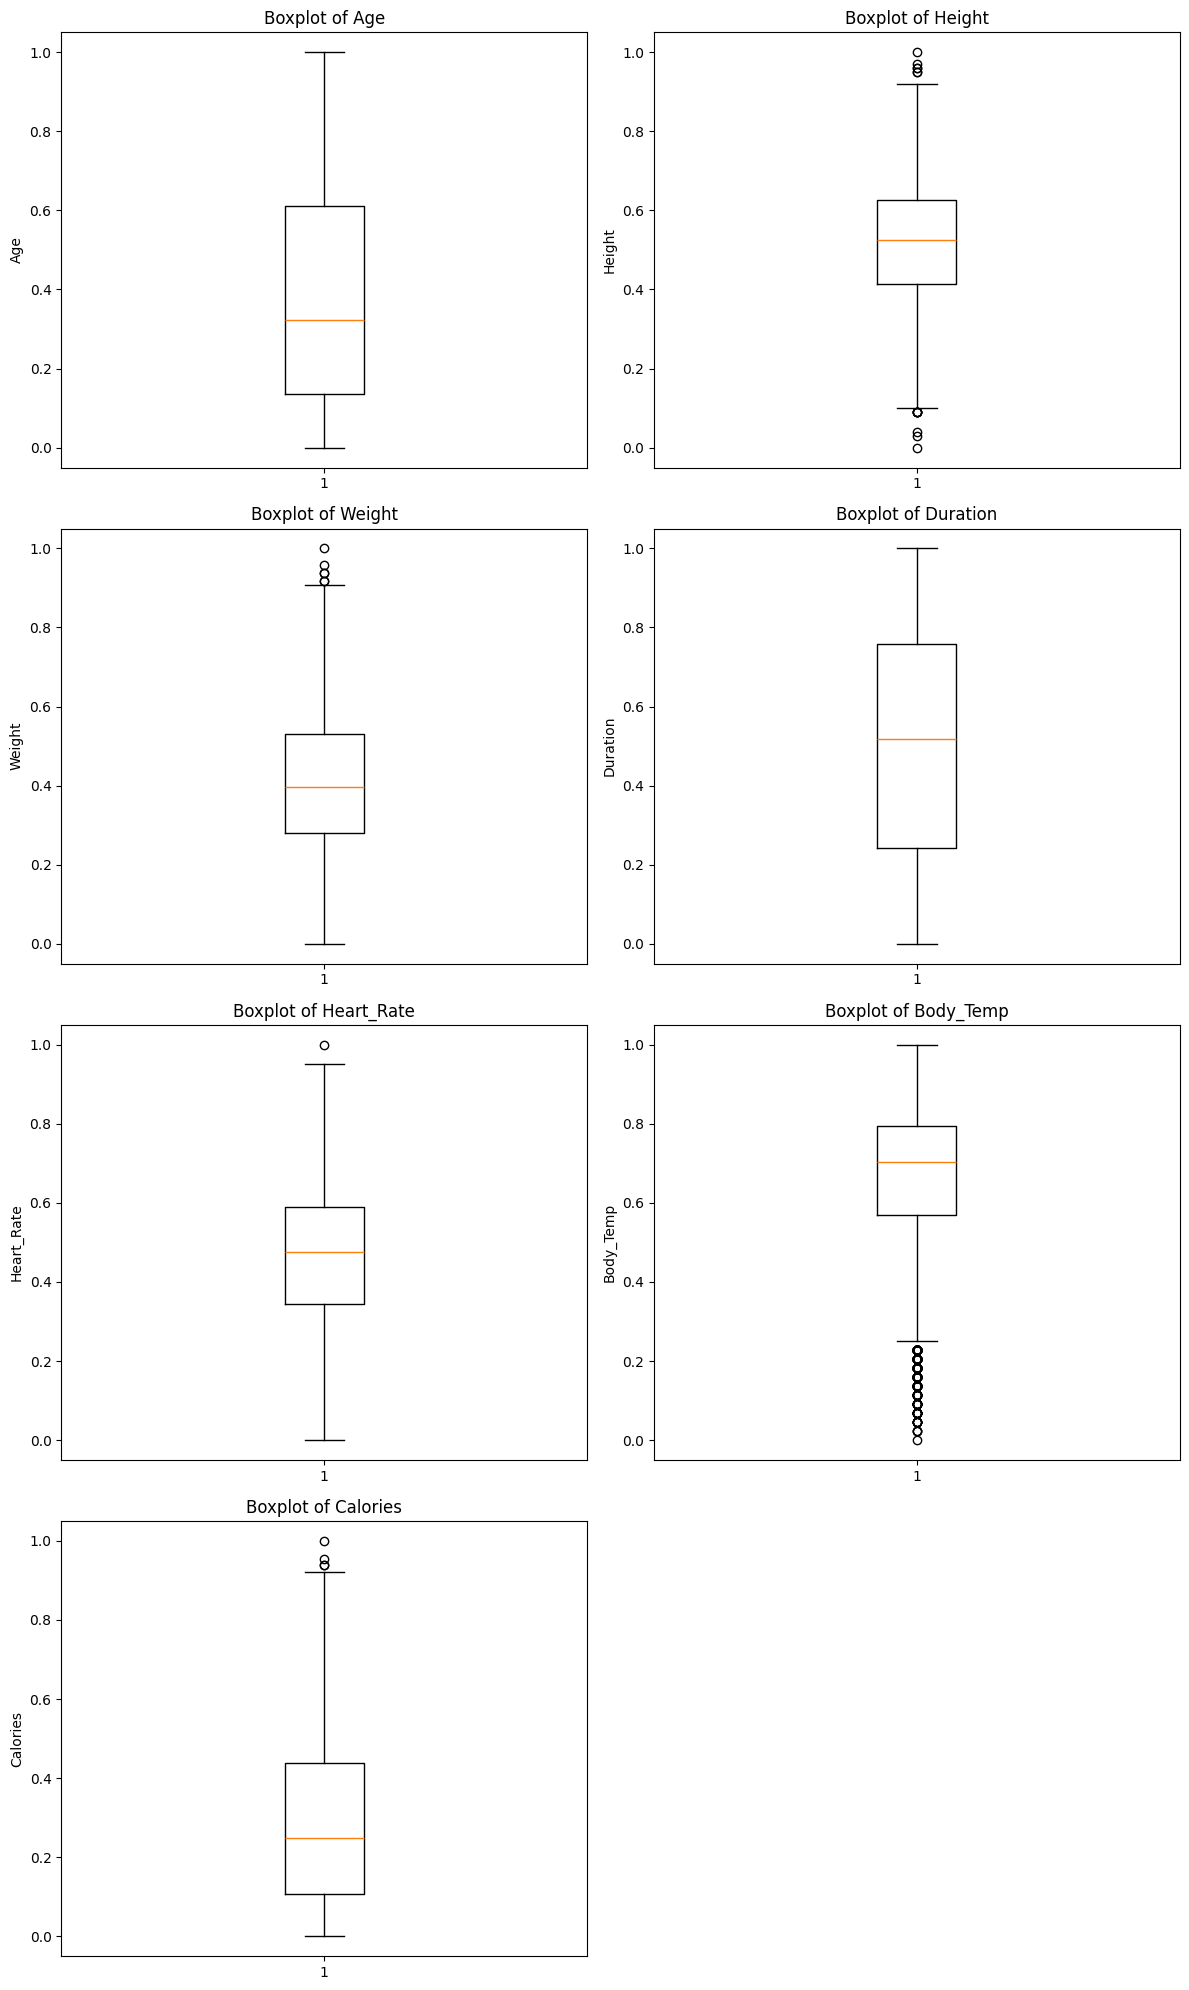

In [9]:
n = len(numeric_features)
cols = 2
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Penanganan Outlier Menggunakan IQR

In [10]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df[numeric_features] < lower_bound) | (df[numeric_features] > upper_bound)
df = df[~outlier_mask.any(axis=1)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14520 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      14520 non-null  object 
 1   Age         14520 non-null  float64
 2   Height      14520 non-null  float64
 3   Weight      14520 non-null  float64
 4   Duration    14520 non-null  float64
 5   Heart_Rate  14520 non-null  float64
 6   Body_Temp   14520 non-null  float64
 7   Calories    14520 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1020.9+ KB


# EXPLORATORY DATA ANALYSIS ( EDA )

## UNIVARIATE ANALYSIS

### Categorical Features

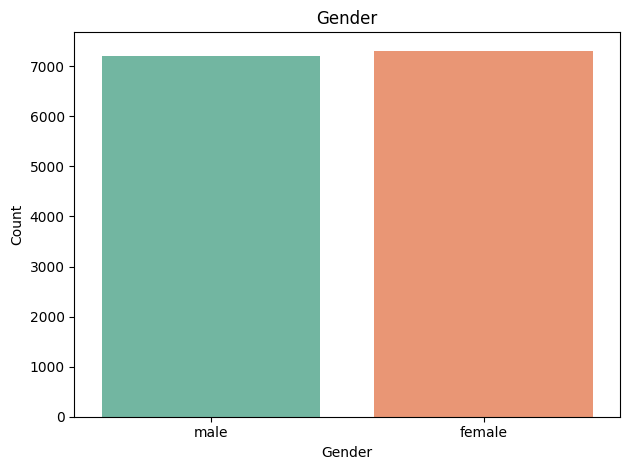

In [11]:
sns.countplot(data=df, x='Gender', hue='Gender', palette='Set2', legend=False)
plt.title(f'Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [12]:
df['Gender'].value_counts()

,count
Gender,
female,7312
male,7208


- Berdasarkan data diatas, dapat di simpulkan bahwa jumlah gender laki laki dan perempuan didataset ini hampir seimbang

### NUMERIC FEATURES

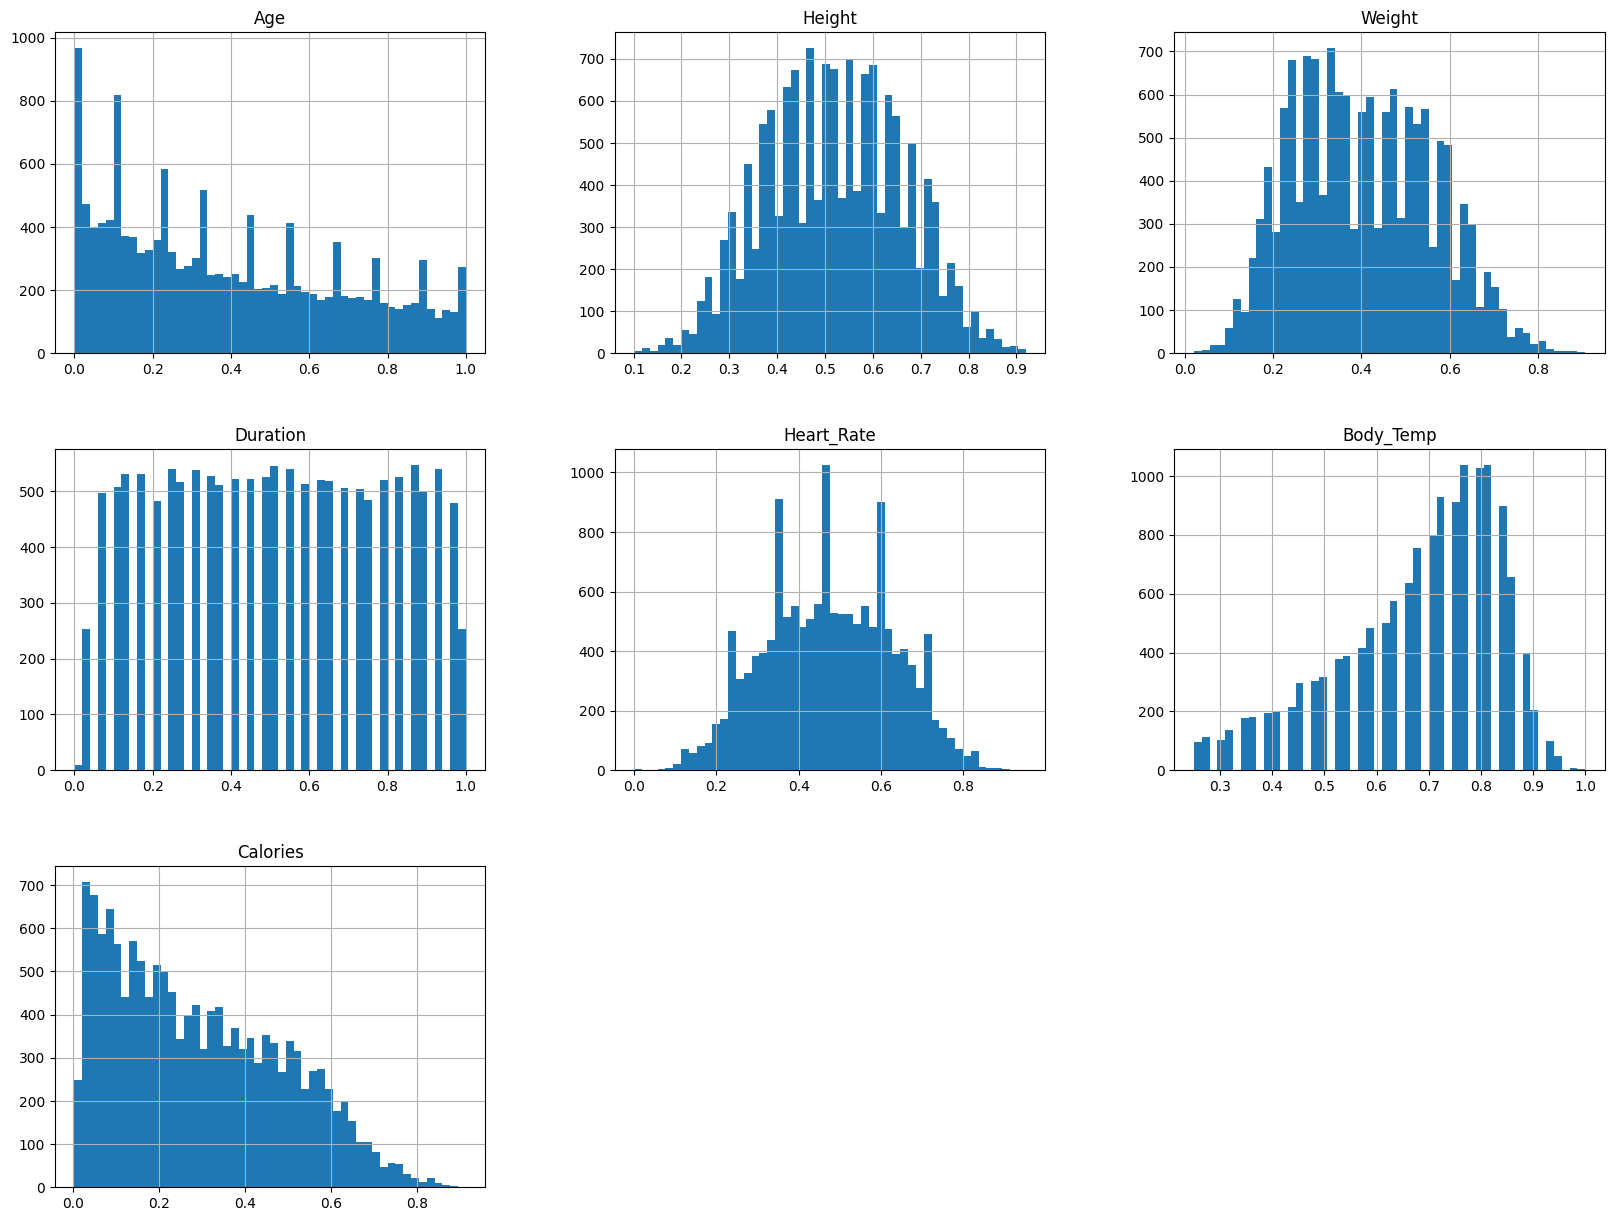

In [13]:
df[numeric_features].hist(bins=50, figsize=(20,15))
plt.show()

### BERDASARKAN DISTRIBUSI DIATAS, DAPAT DISIMPULKAN BAHWA :
1. Feature Age memiliki Distribusi right-skewed, yang artinya Data ini didominasi oleh usia yang lebih muda, makin sedikit yang berusia tua.

2. Feature Height memiliki Distribusi normal, yang artinya Sebagian besar orang berada di tinggi badan rata-rata, sedikit yang sangat pendek atau sangat tinggi.

3. Feature Weight memiliki Distribusi right-skewed, yang artinya Banyak orang dengan berat badan sedang, tapi masih ada cukup banyak yang beratnya di atas rata-rata.

4. Feature Duration memiliki Distribusinya relatif datar (uniform distribution), yang artinya Durasi aktivitas cukup tersebar merata, tidak terkonsentrasi pada satu nilai saja.

5. Feature Heart_Rate memiliki Distribusi mendekati normal tapi banyak puncak yang cukup tajam (spiky)

6. Feature Body_Temp memiliki Distribusi left-skewed, yang artinya: Sebagian besar suhu tubuh berkumpul di nilai tinggi (yang normal).

7. Feature Calories memiliki Distribusi right-skewed, yang artinya: Sebagian besar aktivitas membakar kalori dalam jumlah kecil, hanya sedikit yang besar.

## MULTIVARIATE ANALYSIS

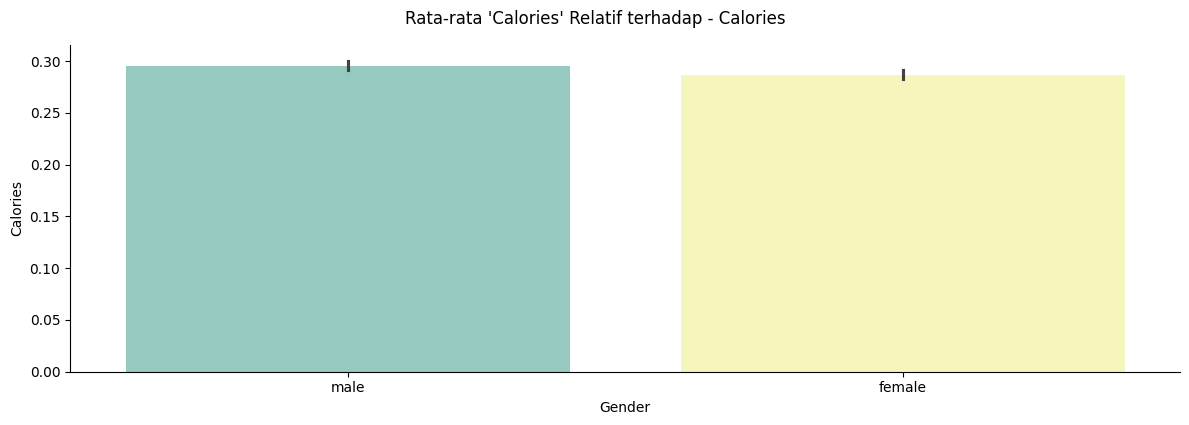

In [14]:
g = sns.catplot(
     x='Gender', y="Calories", kind="bar", dodge=False,
     height=4, aspect=3, data=df, palette="Set3", hue='Gender', legend=False
)
g.fig.suptitle(f"Rata-rata 'Calories' Relatif terhadap - {col}", y=1.05)
plt.show()


**INSIGHT**
- Laki-laki (male) memiliki rata-rata pembakaran kalori sedikit lebih tinggi dibanding perempuan.
- Gender mungkin berpengaruh terhadap jumlah kalori yang terbakar, namun pengaruhnya cukup kecil.
- Bisa jadi karena perbedaan biologis (massa otot, berat badan) antara laki-laki dan perempuan.

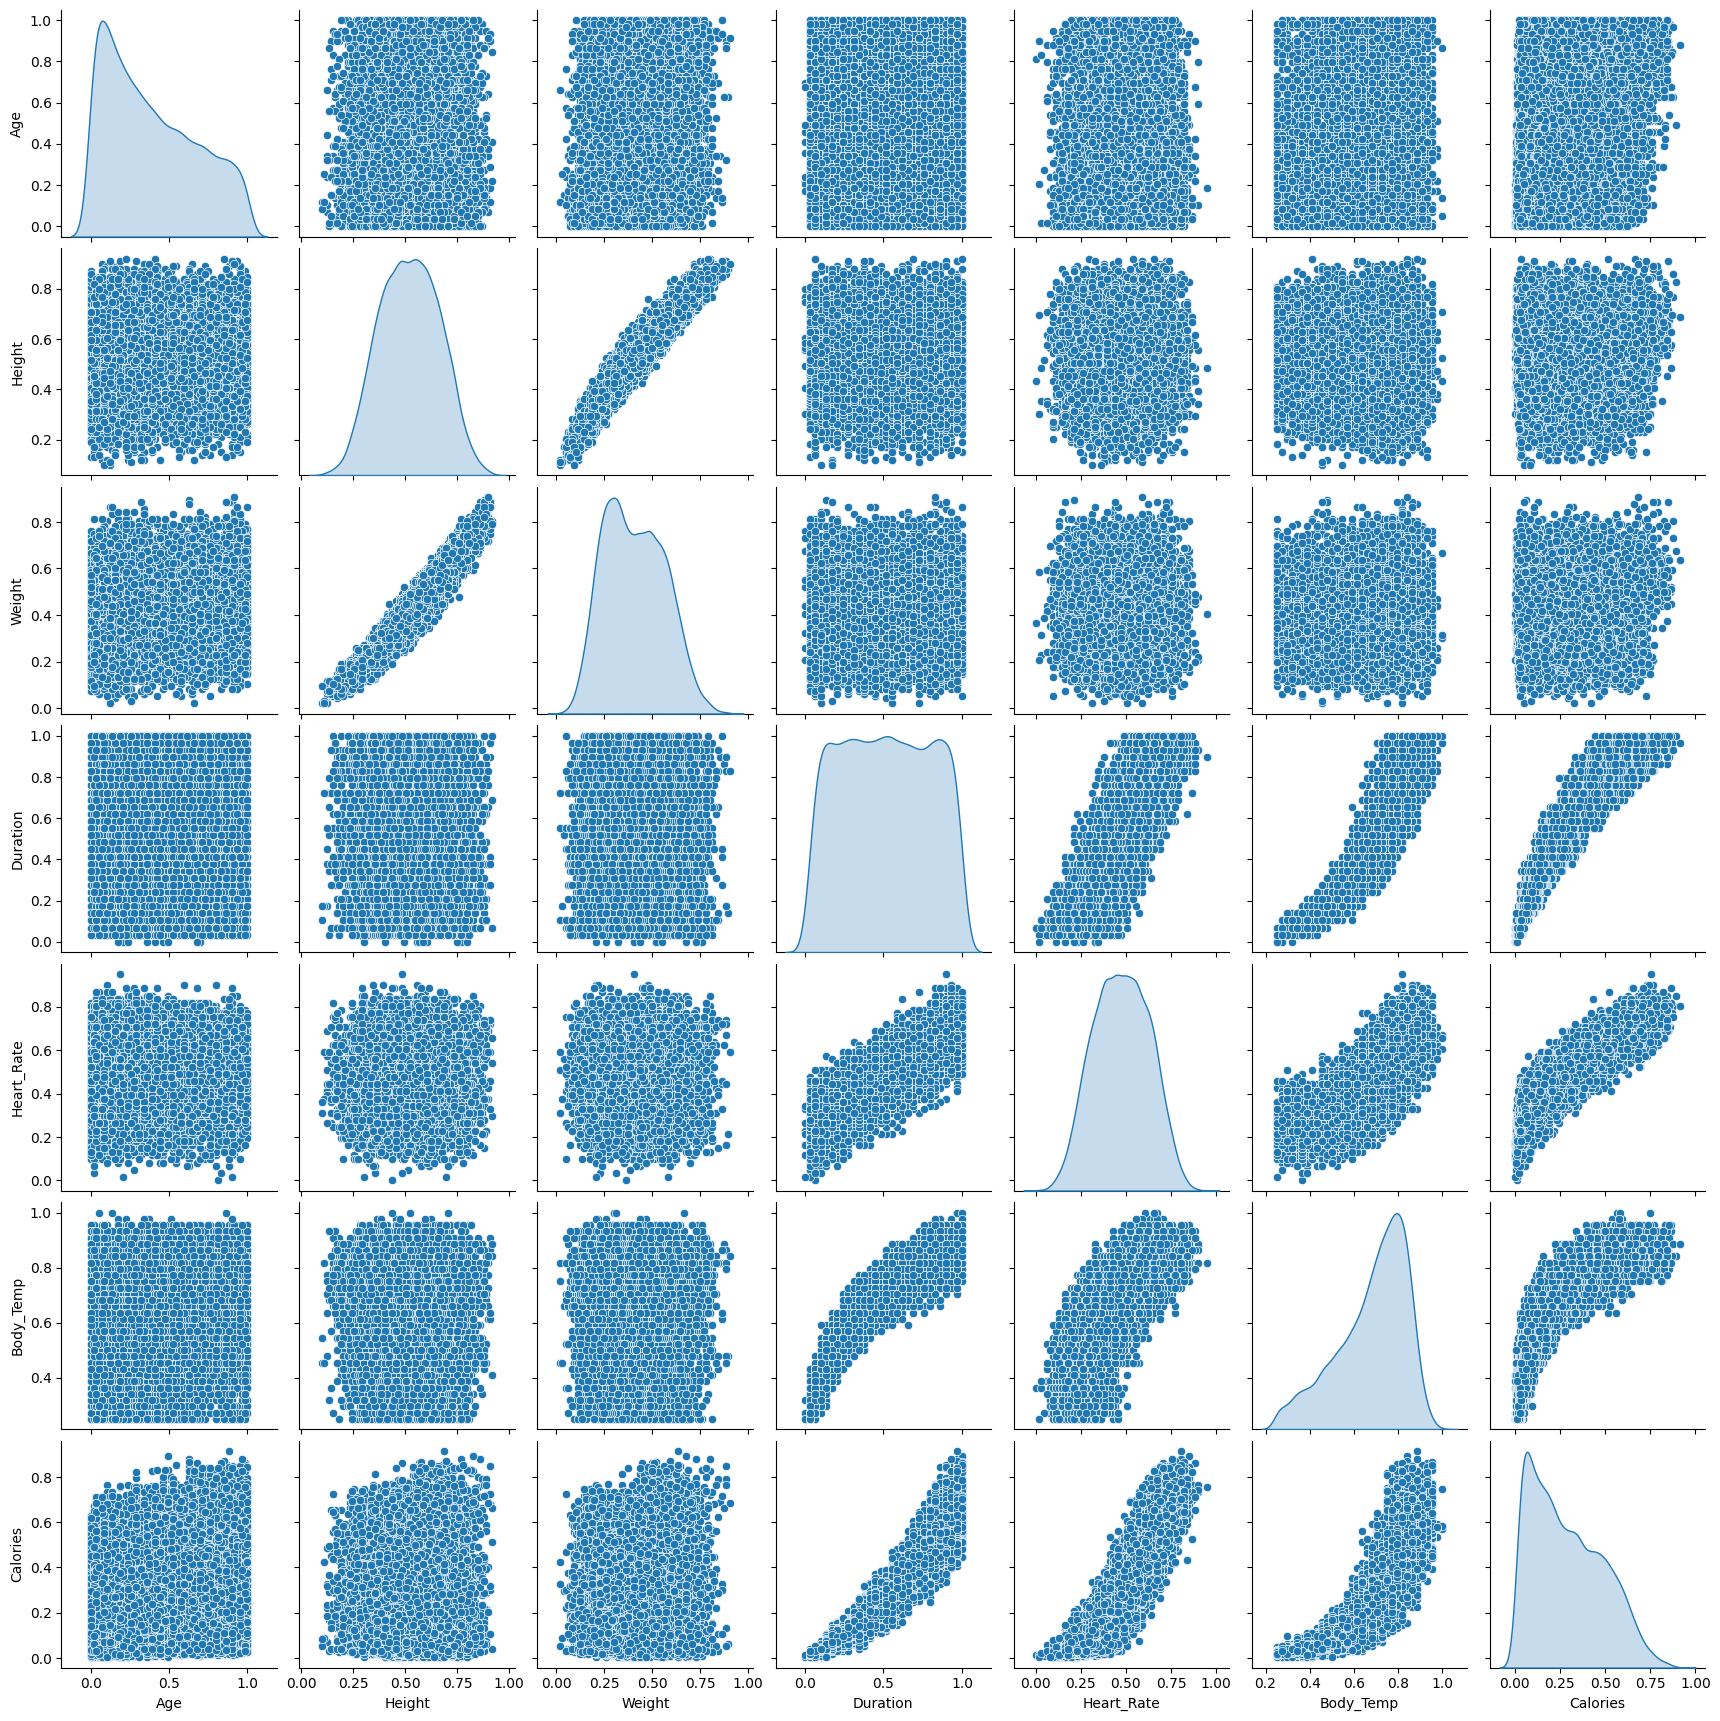

In [15]:
sns.pairplot(df[numeric_features], diag_kind = 'kde')
plt.show()

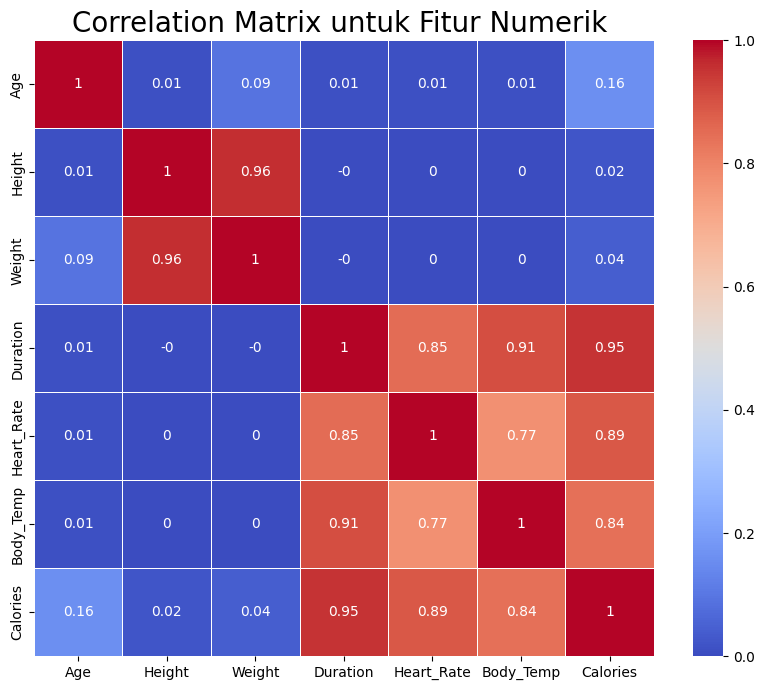

In [16]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_features].corr().round(2)

sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, )
plt.title("Correlation Matrix untuk Fitur Numerik ", size=20)
plt.show()

**INSIGHT**
- Fitur seperti Duration, Heart_Rate, dan Body_Temp menunjukkan hubungan yang kuat dan pola yang jelas terhadap Calories yang terbakar. Hal ini juga diperkuat oleh nilai korelasi yang tinggi masing-masing sebesar 0.95, 0.89, dan 0.84.

- Age menunjukkan korelasi yang lebih rendah (0.16), namun masih cukup untuk dipertimbangkan sebagai fitur dalam pemodelan, terutama karena usia bisa memengaruhi performa dan metabolisme seseorang saat beraktivitas fisik.

- Di sisi lain, Height dan Weight memiliki nilai korelasi yang sangat rendah terhadap Calories (masing-masing 0.02 dan 0.04), dan juga tidak menunjukkan pola hubungan yang jelas pada pairplot. Oleh karena itu, keduanya cenderung kurang relevan dalam memengaruhi jumlah kalori yang terbakar pada dataset ini.

### Menghpus kolom Height dan Weiht yang memiliki korelasi kecil dengan target

In [17]:
df.drop(['Height', 'Weight'], inplace=True, axis=1)
df.head()

,Gender,Age,Duration,Heart_Rate,Body_Temp,Calories
0,male,0.813559,0.965517,0.622951,0.840909,0.734824
1,female,0.000000,0.448276,0.442623,0.727273,0.207668
2,male,0.830508,0.137931,0.344262,0.363636,0.079872
3,female,0.237288,0.413793,0.540984,0.772727,0.223642
4,female,0.118644,0.310345,0.229508,0.613636,0.108626


## Encode menggunakan One Hot Encoding untuk kolom Gender


In [18]:
# encoding
df = pd.concat([df, pd.get_dummies(df['Gender'], prefix='Gender')],axis=1)
df.drop(['Gender'], inplace=True, axis=1)
df.head()

,Age,Duration,Heart_Rate,Body_Temp,Calories,Gender_female,Gender_male
0,0.813559,0.965517,0.622951,0.840909,0.734824,False,True
1,0.000000,0.448276,0.442623,0.727273,0.207668,True,False
2,0.830508,0.137931,0.344262,0.363636,0.079872,False,True
3,0.237288,0.413793,0.540984,0.772727,0.223642,True,False
4,0.118644,0.310345,0.229508,0.613636,0.108626,True,False


### SPLIT DATA

In [19]:
X = df.drop(["Calories"],axis =1)
y = df["Calories"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)

In [20]:
print(f'Total # of sample in whole dataset: {len(X)}')
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Total # of sample in test dataset: {len(X_test)}')

Total # of sample in whole dataset: 14520
Total # of sample in train dataset: 11616
Total # of sample in test dataset: 2904


In [21]:
df.describe()

,Age,Duration,Heart_Rate,Body_Temp,Calories
count,14520.000000,14520.000000,14520.000000,14520.000000,14520.000000
mean,0.386888,0.516220,0.474627,0.680507,0.291189
std,0.288056,0.277941,0.153275,0.155835,0.196404
min,0.000000,0.000000,0.000000,0.250000,0.003195
25%,0.135593,0.275862,0.360656,0.590909,0.121406
50%,0.338983,0.517241,0.475410,0.727273,0.258786
75%,0.610169,0.758621,0.590164,0.795455,0.444089
max,1.000000,1.000000,0.950820,1.000000,0.913738


# **MODELLING**

## Membuat data frame untuk menampung nilai evaluasi

In [22]:
models = pd.DataFrame(index=['train_mse', 'test_mse'],
                      columns=['KNN', 'RF',])

## Menggunakan K-Nearest Neighbor ( KNN )

In [23]:
# Training
knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train, y_train)

# Testing
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)


models.loc['train_mse','KNN'] = mean_squared_error(y_train, y_pred_train)
models.loc['test_mse','KNN'] = mean_squared_error(y_test, y_pred_test)

## Menggunakan Random Forest Regressor

In [24]:
# Training
RF = RandomForestRegressor(n_estimators=50, max_depth=16, random_state=55, n_jobs=-1)
RF.fit(X_train, y_train)

# Testing
y_pred_train = RF.predict(X_train)
y_pred_test = RF.predict(X_test)

models.loc['train_mse','RF'] = mean_squared_error(y_train, y_pred_train)
models.loc['test_mse','RF'] = mean_squared_error(y_test, y_pred_test)

# EVALUASI

In [25]:
models

,KNN,RF
train_mse,0.000148,0.000023
test_mse,0.000196,0.000163


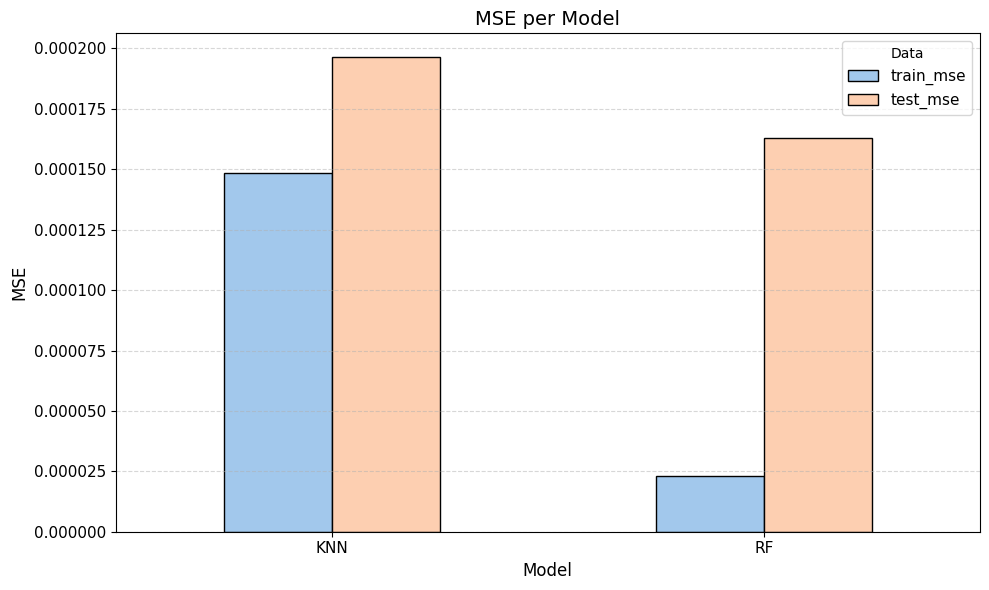

In [26]:
import matplotlib.pyplot as plt

models_plot = models.loc[['train_mse', 'test_mse']].T

ax = models_plot.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#A2C8EC', '#FDCFB1'],
    edgecolor='black'
)

plt.title('MSE per Model', fontsize=14)
plt.ylabel('MSE', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Data', fontsize=11)
plt.tight_layout()
plt.show()


**INSIGHT**
- KNN memiliki nilai train MSE yang lebih tinggi dibanding RF.
- Random Forest menunjukkan train MSE yang sangat rendah, yang mengindikasikan bahwa model ini sangat baik dalam menyesuaikan data training.
- KNN lebih stabil (train vs test MSE tidak terlalu jauh), meskipun performa keseluruhan masih kalah tipis dari RF.